## Import Data & Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

pd.set_option('display.max_columns', None)

## Set Global Variables

In [2]:
df = pd.read_csv('../data/clean_data.csv')

# colors_dl =['#36213e', '#554971', '#63786d', '#8ac6d0', '#b8f3ff']
# colors_ld=['#b8f3ff','#8ac6d0', '#63786d', '#554971', '#36213e']
colors_ld=['#d7f0fa','#92c5de','#4393c3', '#2166ac', '#5e3c99', '#2d1e2f', '#0f0a14']
colors_dl=['#0f0a14', '#2d1e2f', '#5e3c99', '#2166ac', '#4393c3', '#92c5de', '#d7f0fa']

# Resources
#   Color palette: https://coolors.co/palette/36213e-554971-63768d-8ac6d0-b8f3ff
#   Used chat gpt to expand upon original color palette and maintain accessibility

In [3]:
# I'm not understanding why the "unnamed: 0" column is appearing here
df.head()

,Unnamed: 0,S. No.,Date,GAD1_Feeling_nervous,GAD2_Cant_stop_worrying,GAD3_Worrying_too_much,GAD4_Trouble_relaxing,GAD5_Restless,GAD6_Easily_annoyed,GAD7_Feeling_afraid,GADE_Difficulty_in_life_num,GADE_Difficulty_in_life,SWL1_Ideal_life,SWL2_Excellent_conditions,SWL3_Satisfied_with_life,SWL4_Met_wants,SWL5_Change_nothing,Game,Platform,Hours,Earnings,Why_play,League,Non_game_hours,SPIN1_Fear_authority,SPIN2_Distress_blushing,SPIN3_Fear_social_events,SPIN4_Avoid_strangers,SPIN5_Fear_criticism,SPIN6_Avoid_embarrassment,SPIN7_Distress_sweating,SPIN8_Avoid_parties,SPIN9_Avoid_attention,SPIN10_Fear_talking_strangers,SPIN11_Avoid_giving_speeches,SPIN12_Avoid_criticism,SPIN13_Distress_heart,SPIN14_Fear_observation,SPIN15_Fear_embarrassment,SPIN16_Avoid_authority,SPIN17_Distress_trembling,Narcissism,Gender,Age,Work,Degree,Reference,Play_style,Accept,GAD_Total,SWL_Total,SPIN_Total,Residence_ISO3,Birthplace_ISO3
0,0,1,2015-02-17,0,0,0,0,1,0,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15,I play for fun,having fun,unknown,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,Accept,1,23,5,USA,USA
1,1,2,2015-02-17,1,2,2,2,0,1,0,1,Somewhat difficult,3,5,2,5,1,Other,PC,8,I play for fun,having fun,unknown,2,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,8,16,33,USA,USA
2,2,3,2015-02-17,0,2,2,0,0,3,1,0,Not difficult at all,2,6,5,2,2,Other,PC,0,I play for fun,having fun,unknown,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4.0,Female,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,Accept,8,17,31,DEU,DEU
3,3,4,2015-02-17,0,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20,I play for fun,improving,unknown,5,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2.0,Male,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11,USA,USA
4,4,5,2015-02-17,2,1,2,2,2,3,2,2,Very difficult,2,2,4,5,1,Other,"Console (PS, Xbox, ...)",20,I play for fun,having fun,unknown,1,2,0,0,0,1,0,0,4,2,0,1,0,0,0,0,3,0,1.0,Male,19,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,14,14,13,KOR,USA


## Charts for analysis
- **QUESTIONS**:
  - HISTOGRAMS:
    - How did users score on the Generalized Anxiety Disorder (GAD) test?
    - How did users score on the Satisfaction With Live (SWL) test?
    - How did users score on the Social Phobia Inventory (SPIN) test?
    - What is the spread of average weekly hours spent gaming? (scatter plot instead?)
  - STACKED BAR PLOTS: 
    - Does user's sex impact test scores? (test scores / sex) 
    - Does gaming platform impact test scores? (test scores / sex) 
  - GROUPED BAR PLOTS:
    - Do residence and test scores correlate?
  - STACKED LINE GRAPH
    - Is there a correlation between hours played and high test scores?
      - buckets of hours vs test scores

### HISTOGRAMS

In [4]:
average_GAD = df['GAD_Total'].mean()
average_GAD

np.float64(5.445697818032112)

How did users score on the Generalized Anxiety Disorder (GAD) test?

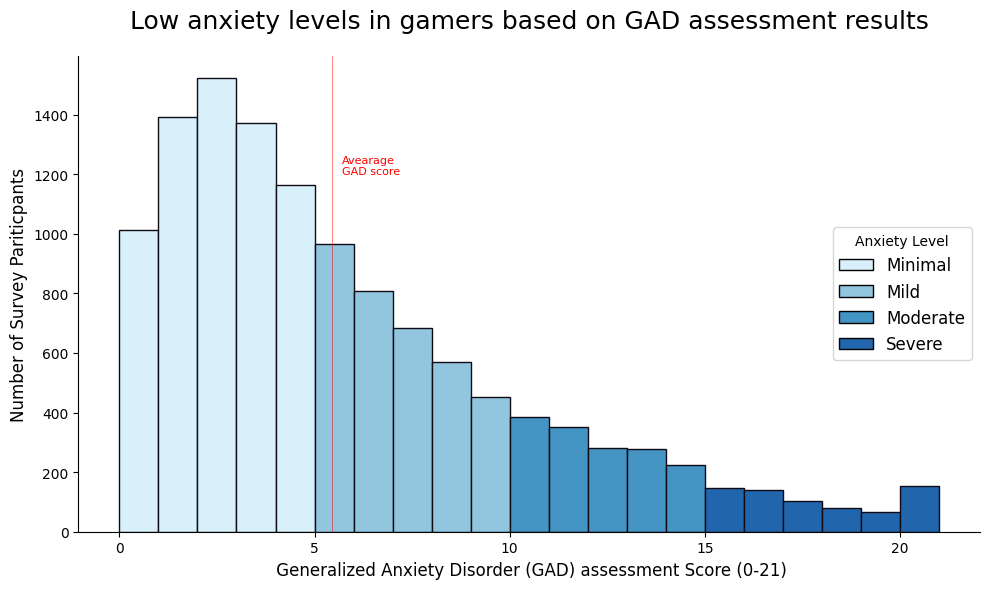

In [ ]:
# Resources: 
#   Custom bin size: https://stackoverflow.com/questions/6986986/bin-size-in-matplotlib-histogram
#   Custom bin colors: https://www.youtube.com/watch?v=mmjMQkUych8 
#   Bin colors with legend: https://stackoverflow.com/questions/43872450/matplotlib-histogram-with-multiple-legend-entries
# Explanation of scores: https://www.hiv.uw.edu/page/mental-health-screening/gad-7

plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(
    df['GAD_Total'],
    bins=21,
    edgecolor=colors_ld[-1]
)

# Remove extra lines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set bin grouping colors
for i in range(0,5):
    patches[i].set_fc(colors_ld[0])
for i in range(5, 10):
    patches[i].set_fc(colors_ld[1])
for i in range(10,15):
    patches[i].set_fc(colors_ld[2])
for i in range(15,21):
    patches[i].set_fc(colors_ld[3])

# create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in [colors_ld[0], colors_ld[1],colors_ld[2], colors_ld[3]]]
labels = ['Minimal', 'Mild', 'Moderate', 'Severe']
plt.legend(
    handles,
    labels,
    title='Anxiety Level',
    loc='center right',
    fontsize=12
    )

# Add average line
ax.axvline(
    average_GAD,
    color="red",
    linewidth = 0.5,
    alpha = .7
)

ax.text(
    average_GAD+0.25,
    1200,
    'Avearage\nGAD score',
    color="red",
    fontsize=8
)

plt.title("Low anxiety levels in gamers based on GAD assessment results", fontsize=18, pad=20)
plt.xlabel(" Generalized Anxiety Disorder (GAD) assessment Score (0-21)", fontsize=12)
plt.ylabel("Number of Survey Pariticpants", fontsize=12)

plt.tight_layout()
# Save figure as image
# plt.savefig('../plots/GAD_score_histogram.png')

plt.show()


How did users score on the Satisfaction with Life (SWL) scale?

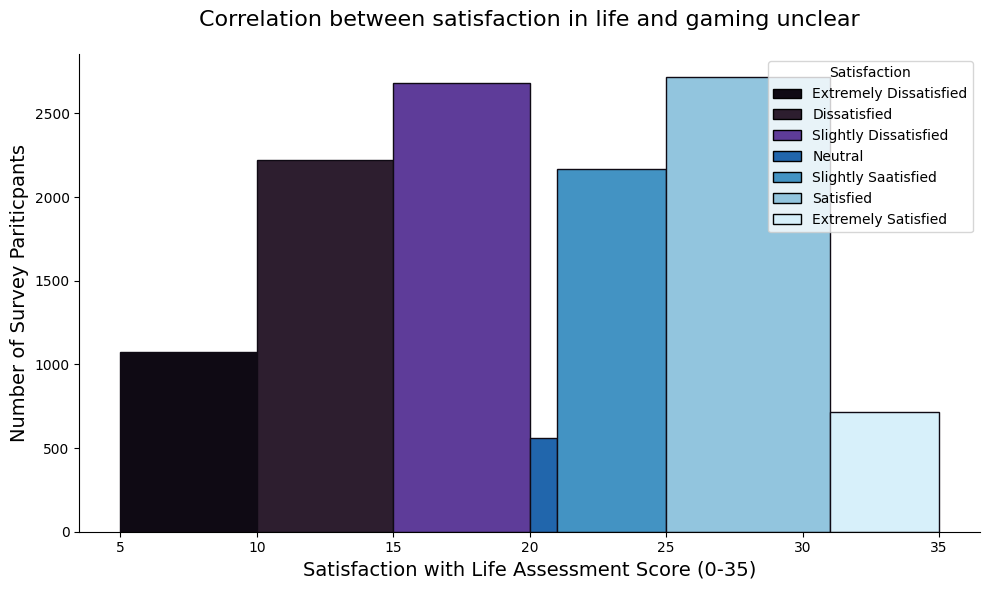

In [ ]:
# Resources: 
#   SWL test: https://novopsych.com/assessments/well-being/satisfaction-with-life-scale-swls/
#   Chat GPT to add 2 more 

plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(
    df['SWL_Total'],
    bins=[5,10,15,20,21,25,31,35],
    edgecolor=colors_dl[0]
)

# Remove extra lines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set bin grouping colors
for i in range(len(n)):
    c=colors_dl[i]
    patches[i].set_fc(c)

# create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in [colors_dl[0], colors_dl[1],colors_dl[2], colors_dl[3],colors_dl[4],colors_dl[5],colors_dl[6]]]
labels = ['Extremely Dissatisfied', 'Dissatisfied', 'Slightly Dissatisfied', 'Neutral', 'Slightly Saatisfied', 'Satisfied', 'Extremely Satisfied']
plt.legend(
    handles,
    labels,
    title='Satisfaction',
    loc='best',
    fontsize=10
    )

plt.title("Correlation between satisfaction in life and gaming unclear", fontsize=16, pad=20)
plt.xlabel("Satisfaction with Life Assessment Score (0-35)", fontsize=14)
plt.ylabel("Number of Survey Pariticpants", fontsize=14)

# || POTENTIALLY DO A BOX AND WHISKERS PLOT OR HEAT MAP FOR THIS ONE ||

plt.tight_layout()
# Save figure as image
# plt.savefig('../plots/SWL_score_histogram.png')

plt.show()

How did users score on the Generalized Anxiety Disorder (GAD) test?

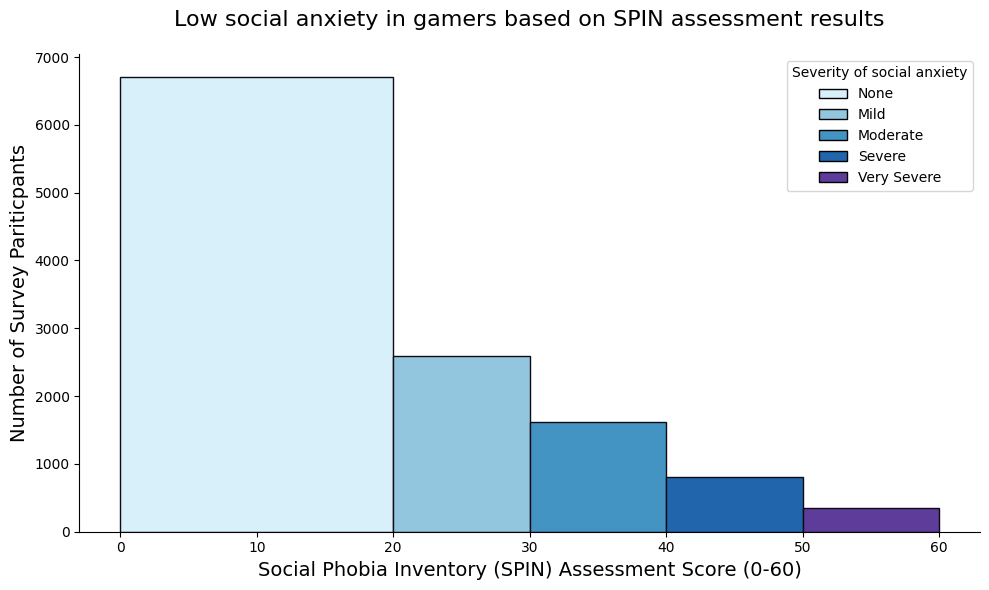

In [ ]:
# Resources: 
#   SPIN test information: https://greenspacehealth.com/en-us/social-anxiety-spin/

plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(
    df['SPIN_Total'],
    bins=[0, 20, 30, 40, 50, 60],
    edgecolor=colors_ld[-1]
)

# Remove extra lines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set bin grouping colors
for i in range(len(n)):
    c=colors_ld[i]
    patches[i].set_fc(c)

# create legend
handles = [Rectangle((0,0),1,1,color=c,ec="k") for c in [colors_ld[0], colors_ld[1],colors_ld[2], colors_ld[3], colors_ld[4]]]
labels = ['None', 'Mild', 'Moderate', 'Severe', 'Very Severe']
plt.legend(
    handles,
    labels,
    title='Severity of social anxiety',
    loc='best',
    fontsize=10
    )

plt.title("Low social anxiety in gamers based on SPIN assessment results", fontsize=16, pad=20)
plt.xlabel("Social Phobia Inventory (SPIN) Assessment Score (0-60)", fontsize=14)
plt.ylabel("Number of Survey Pariticpants", fontsize=14)

plt.tight_layout()
# Save figure as image
# plt.savefig('../plots/SPIN_score_histogram.png')

plt.show()

### BAR PLOT

How many average hours did the top 5 countries who participated in the survey play per week?

In [8]:
top5_countries = df['Residence_ISO3'].value_counts().head(5).index

top5_countries_df = df[df['Residence_ISO3'].isin(top5_countries)]
top5_countries_df.head()

,Unnamed: 0,S. No.,Date,GAD1_Feeling_nervous,GAD2_Cant_stop_worrying,GAD3_Worrying_too_much,GAD4_Trouble_relaxing,GAD5_Restless,GAD6_Easily_annoyed,GAD7_Feeling_afraid,GADE_Difficulty_in_life_num,GADE_Difficulty_in_life,SWL1_Ideal_life,SWL2_Excellent_conditions,SWL3_Satisfied_with_life,SWL4_Met_wants,SWL5_Change_nothing,Game,Platform,Hours,Earnings,Why_play,League,Non_game_hours,SPIN1_Fear_authority,SPIN2_Distress_blushing,SPIN3_Fear_social_events,SPIN4_Avoid_strangers,SPIN5_Fear_criticism,SPIN6_Avoid_embarrassment,SPIN7_Distress_sweating,SPIN8_Avoid_parties,SPIN9_Avoid_attention,SPIN10_Fear_talking_strangers,SPIN11_Avoid_giving_speeches,SPIN12_Avoid_criticism,SPIN13_Distress_heart,SPIN14_Fear_observation,SPIN15_Fear_embarrassment,SPIN16_Avoid_authority,SPIN17_Distress_trembling,Narcissism,Gender,Age,Work,Degree,Reference,Play_style,Accept,GAD_Total,SWL_Total,SPIN_Total,Residence_ISO3,Birthplace_ISO3
0,0,1,2015-02-17,0,0,0,0,1,0,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15,I play for fun,having fun,unknown,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,Accept,1,23,5,USA,USA
1,1,2,2015-02-17,1,2,2,2,0,1,0,1,Somewhat difficult,3,5,2,5,1,Other,PC,8,I play for fun,having fun,unknown,2,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,8,16,33,USA,USA
2,2,3,2015-02-17,0,2,2,0,0,3,1,0,Not difficult at all,2,6,5,2,2,Other,PC,0,I play for fun,having fun,unknown,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4.0,Female,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,Accept,8,17,31,DEU,DEU
3,3,4,2015-02-17,0,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20,I play for fun,improving,unknown,5,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2.0,Male,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11,USA,USA
5,5,6,2015-02-17,0,0,0,0,0,1,0,0,Not difficult at all,3,5,3,3,3,Other,"Console (PS, Xbox, ...)",4,I play for fun,relaxing,-,0,1,1,2,3,2,1,0,0,0,1,0,0,0,1,1,0,0,2.0,Male,24,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with real life friends,Accept,1,17,13,USA,USA


In [24]:
residence_GAD_scores = top5_countries_df.groupby('Residence_ISO3')['GAD_Total'].mean()
residence_SWL_scores = top5_countries_df.groupby('Residence_ISO3')['SWL_Total'].mean()
residence_SPIN_scores = top5_countries_df.groupby('Residence_ISO3')['SPIN_Total'].mean()
residence_avg_hrs = top5_countries_df.groupby('Residence_ISO3')['Hours'].mean()

countries_hrs_df = pd.concat([
    residence_avg_hrs
    ], axis=1).reset_index()

# countries_df
type(residence_avg_hrs)

pandas.Series

In [ ]:
# avg_hrs_country = countries_df.groupby('Residence_ISO3')['Hours'].mean().sort_values(ascending=False)
# type(avg_hrs_country)

pandas.Series

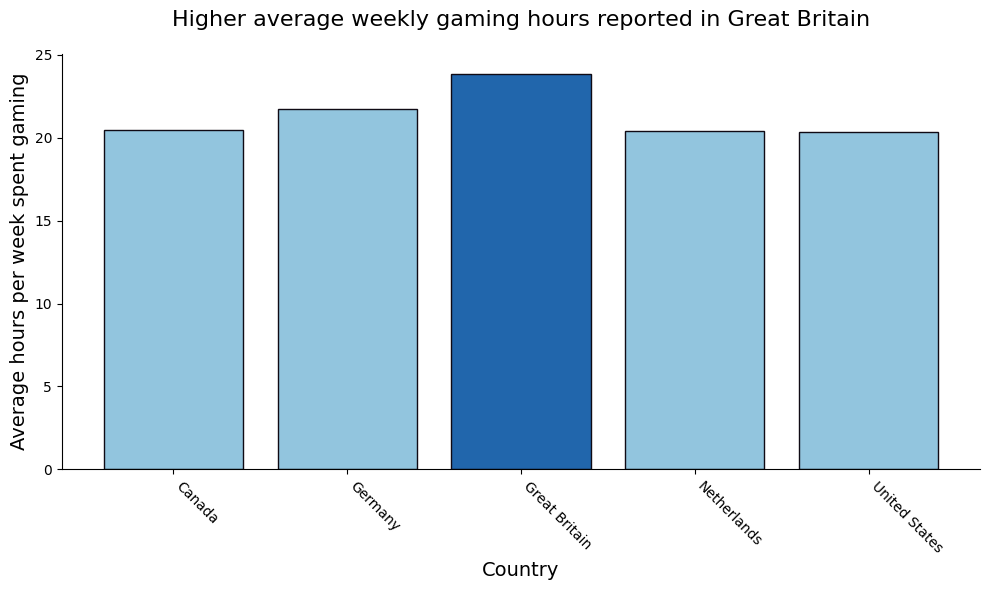

In [25]:
plt.figure(figsize=(10,6))
colors = [colors_dl[5]] * len(residence_avg_hrs)

# Highlight the highest value
max_index=residence_avg_hrs.idxmax()
highlight_position = residence_avg_hrs.index.get_loc(max_index)
colors[highlight_position] = colors_dl[3]

plt.bar(
    residence_avg_hrs.index,
    residence_avg_hrs.values,
    color= colors,
    edgecolor = colors_dl[0])

# Remove extra lines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Country', fontsize=14)
plt.ylabel('Average hours per week spent gaming', fontsize=14)
plt.title('Higher average weekly gaming hours reported in Great Britain', fontsize=16, pad=20)
plt.xticks(
        ['GBR', 'DEU', 'CAN', 'NLD', 'USA'],
        ['Great Britain', 'Germany', 'Canada', 'Netherlands', 'United States'],
        rotation=-45,
        ha='left')

plt.tight_layout()
# Save figure as image
# plt.savefig('../plots/game_hours_country_barplot.png')

plt.show()

### STACKED BAR PLOT
- Reference: https://www.geeksforgeeks.org/data-visualization/plotting-categorical-variable-with-stacked-bar-plot/
- Gender / scores for each test (Done as grouped bar chart before)

Do gender and overall test scores correlate?

In [12]:
# Reference: Combine series into df https://stackoverflow.com/questions/18062135/combining-two-series-into-a-dataframe-in-pandas

gender_GAD_scores = df.groupby('Gender')['GAD_Total'].mean() 
gender_SWL_scores = df.groupby('Gender')['SWL_Total'].mean()
gender_SPIN_scores = df.groupby('Gender')['SPIN_Total'].mean()

gender_df = pd.concat([
    gender_GAD_scores,
    gender_SWL_scores,
    gender_SPIN_scores
], axis=1).reset_index()

gender_df

,Gender,GAD_Total,SWL_Total,SPIN_Total
0,Female,7.791356,18.856930,28.236960
1,Male,5.291802,19.656138,19.698836
2,Other,9.555556,15.488889,28.933333


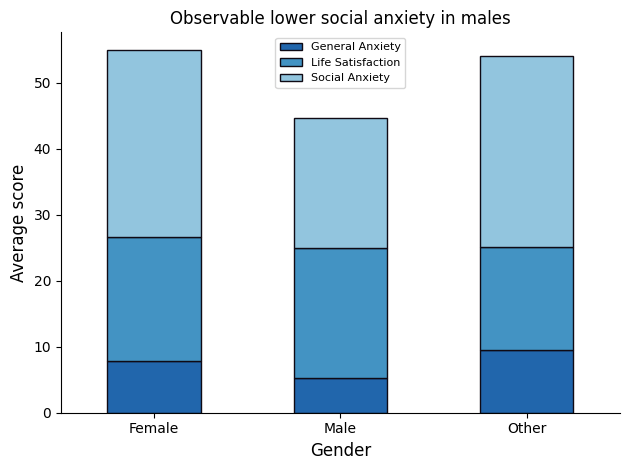

In [ ]:
# Reference: https://www.geeksforgeeks.org/python/create-a-grouped-bar-plot-in-matplotlib/
#   Chat GPT helped correct the color indexing and the need to use the ax properties to customize the legend and axes labels

ax = gender_df.plot(
    x="Gender",
    kind='bar',
    stacked=True,
    title='Observable lower social anxiety in males',
    color=colors_dl[3:6],
    edgecolor=colors_dl[0])

ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('Gender', fontsize=12)
ax.legend(['General Anxiety', 'Life Satisfaction', 'Social Anxiety'],
        loc='best',
        fontsize=8)


plt.ylabel("Average score", fontsize=12)
plt.xticks(rotation=0)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save figure as image
# plt.savefig('../plots/scores_stacked_bar_chart.png')

plt.show()

Do gaming platform and overall test scores correlate?

In [14]:
platform_GAD_scores = df.groupby('Platform')['GAD_Total'].mean() 
platform_SWL_scores = df.groupby('Platform')['SWL_Total'].mean()
platform_SPIN_scores = df.groupby('Platform')['SPIN_Total'].mean()

platform_df = pd.concat([
    platform_GAD_scores,
    platform_SWL_scores,
    platform_SPIN_scores
], axis=1).reset_index()

platform_df

,Platform,GAD_Total,SWL_Total,SPIN_Total
0,"Console (PS, Xbox, ...)",5.475490,20.906863,21.686275
1,PC,5.441201,19.574065,20.169770
2,Smartphone / Tablet,7.947368,19.631579,26.263158


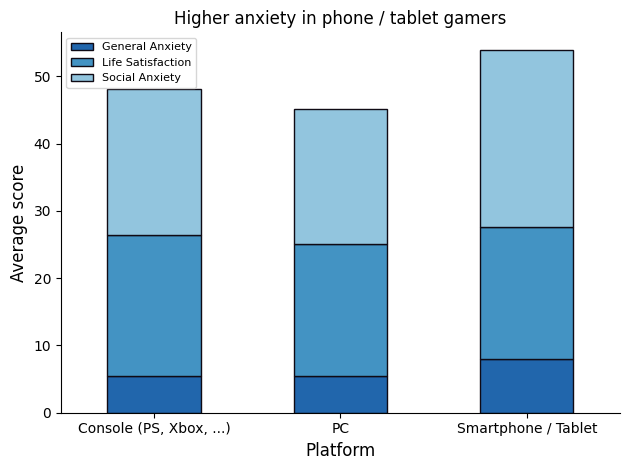

In [ ]:
ax = platform_df.plot(
    x='Platform',
    kind='bar',
    stacked=True,
    title='Higher anxiety in phone / tablet gamers',
    color=colors_dl[3:6],
    edgecolor=colors_dl[0]
)

ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('Platform', fontsize=12)
ax.legend(['General Anxiety', 'Life Satisfaction', 'Social Anxiety'],
        loc='best',
        fontsize=8)

plt.ylabel("Average score", fontsize=12)
plt.xticks(rotation=0)

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save figure as image
# plt.savefig('../plots/platform_scores_stacked_bar_chart.png')

plt.show()

Do geographical location and overall test scores correlate?

In [27]:
residence_GAD_scores = top5_countries_df.groupby('Residence_ISO3')['GAD_Total'].mean()
residence_SWL_scores = top5_countries_df.groupby('Residence_ISO3')['SWL_Total'].mean()
residence_SPIN_scores = top5_countries_df.groupby('Residence_ISO3')['SPIN_Total'].mean()

countries_df = pd.concat([
    residence_GAD_scores,
    residence_SWL_scores,
    residence_SPIN_scores
    ], axis=1).reset_index()

countries_df

,Residence_ISO3,GAD_Total,SWL_Total,SPIN_Total
0,CAN,5.444321,19.572383,20.819599
1,DEU,5.014914,19.889325,19.104396
2,GBR,6.231195,18.613938,22.361726
3,NLD,4.806522,20.371739,17.797826
4,USA,5.531160,20.094919,20.118648


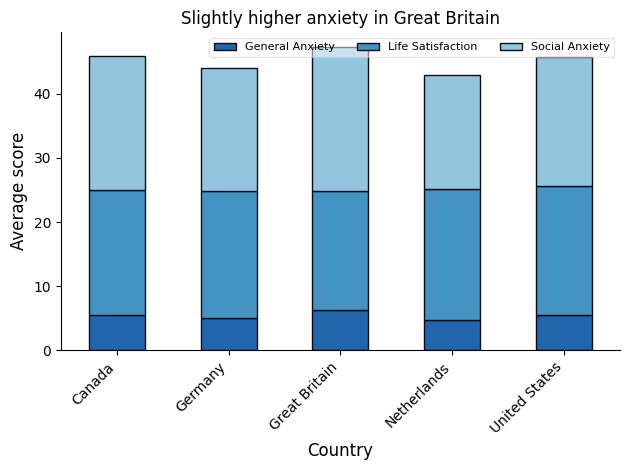

In [28]:
ax = countries_df.plot(
    x='Residence_ISO3',
    kind='bar',
    stacked=True,
    title='Slightly higher anxiety in Great Britain',
    color=colors_dl[3:6],
    edgecolor=colors_dl[0]
)

ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('Country', fontsize=12)
ax.set_xticklabels(['Canada', 'Germany', 'Great Britain', 'Netherlands', 'United States'])
ax.legend(['General Anxiety', 'Life Satisfaction', 'Social Anxiety'],
        loc='best',
        fontsize=8,
        framealpha=.5,
        ncol=3)

plt.ylabel("Average score", fontsize=12)
plt.xticks(rotation=45, ha='right')

ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save figure as image
# plt.savefig('../plots/country_scores_stacked_bar_chart.png')

plt.show()

### BOX PLOT
- How do the ranges of test scores fall?

In [29]:
df.head()

,Unnamed: 0,S. No.,Date,GAD1_Feeling_nervous,GAD2_Cant_stop_worrying,GAD3_Worrying_too_much,GAD4_Trouble_relaxing,GAD5_Restless,GAD6_Easily_annoyed,GAD7_Feeling_afraid,GADE_Difficulty_in_life_num,GADE_Difficulty_in_life,SWL1_Ideal_life,SWL2_Excellent_conditions,SWL3_Satisfied_with_life,SWL4_Met_wants,SWL5_Change_nothing,Game,Platform,Hours,Earnings,Why_play,League,Non_game_hours,SPIN1_Fear_authority,SPIN2_Distress_blushing,SPIN3_Fear_social_events,SPIN4_Avoid_strangers,SPIN5_Fear_criticism,SPIN6_Avoid_embarrassment,SPIN7_Distress_sweating,SPIN8_Avoid_parties,SPIN9_Avoid_attention,SPIN10_Fear_talking_strangers,SPIN11_Avoid_giving_speeches,SPIN12_Avoid_criticism,SPIN13_Distress_heart,SPIN14_Fear_observation,SPIN15_Fear_embarrassment,SPIN16_Avoid_authority,SPIN17_Distress_trembling,Narcissism,Gender,Age,Work,Degree,Reference,Play_style,Accept,GAD_Total,SWL_Total,SPIN_Total,Residence_ISO3,Birthplace_ISO3
0,0,1,2015-02-17,0,0,0,0,1,0,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15,I play for fun,having fun,unknown,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,Accept,1,23,5,USA,USA
1,1,2,2015-02-17,1,2,2,2,0,1,0,1,Somewhat difficult,3,5,2,5,1,Other,PC,8,I play for fun,having fun,unknown,2,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,8,16,33,USA,USA
2,2,3,2015-02-17,0,2,2,0,0,3,1,0,Not difficult at all,2,6,5,2,2,Other,PC,0,I play for fun,having fun,unknown,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4.0,Female,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,Accept,8,17,31,DEU,DEU
3,3,4,2015-02-17,0,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20,I play for fun,improving,unknown,5,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2.0,Male,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11,USA,USA
4,4,5,2015-02-17,2,1,2,2,2,3,2,2,Very difficult,2,2,4,5,1,Other,"Console (PS, Xbox, ...)",20,I play for fun,having fun,unknown,1,2,0,0,0,1,0,0,4,2,0,1,0,0,0,0,3,0,1.0,Male,19,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,Accept,14,14,13,KOR,USA


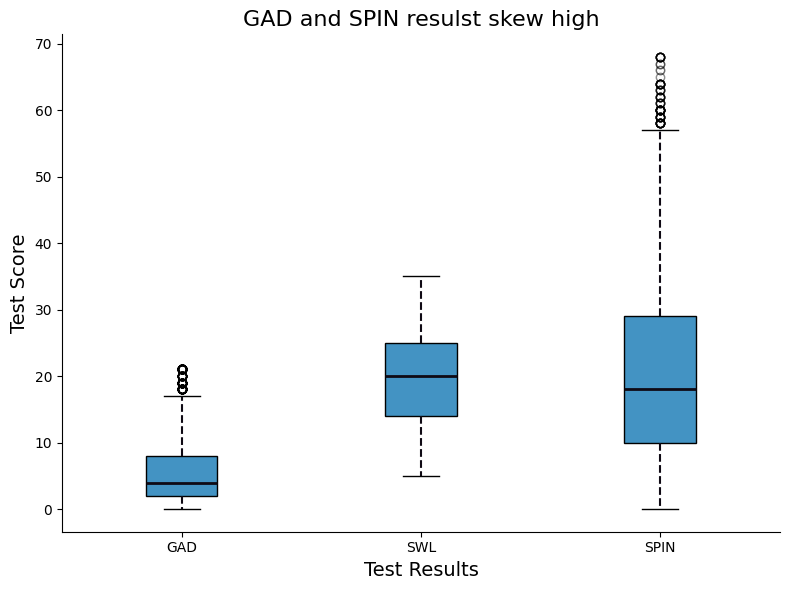

In [ ]:
# Reference: https://www.geeksforgeeks.org/data-visualization/box-plot-in-python-using-matplotlib/

d_GAD = df['GAD_Total']
d_SWL = df['SWL_Total']
d_SPIN = df['SPIN_Total']
d=[d_GAD, d_SWL, d_SPIN]

fig = plt.figure(figsize=(8,6))

# ax = plt.gca()
ax = fig.add_subplot(1,1,1)

bp = ax.boxplot(d, patch_artist=True)

# colors = colors_dl

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(colors_dl[4])

for whisker in bp['whiskers']:
    whisker.set(color = colors_dl[0],
                linewidth=1.5,
                linestyle='--')

for median in bp['medians']:
    median.set(color = colors_dl[0],
                linewidth = 2)

for flier in bp['fliers']:
    flier.set(marker = 'o',
                color=colors_dl[0],
                alpha=0.25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks([1,2,3],['GAD', 'SWL', 'SPIN'])
plt.xlabel('Test Results', fontsize=14)
plt.ylabel('Test Score', fontsize=14)
plt.title('GAD and SPIN resulst skew high', fontsize=16)

plt.tight_layout()

# Save figure as image
# plt.savefig('../plots/scores_box_plot.png')

plt.show()